# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [2]:
df = pd.read_csv('indian_pharmaceutical_products_clean.csv')

# EDA (Exploratory Data Analysis)

1) Viewing the data

In [3]:
df.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


In [4]:
df.columns

Index(['product_id', 'brand_name', 'manufacturer', 'price_inr',
       'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit',
       'num_active_ingredients', 'primary_ingredient', 'primary_strength',
       'active_ingredients', 'therapeutic_class', 'packaging_raw',
       'manufacturer_raw'],
      dtype='object')

In [5]:
df.shape

(253973, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  object 
 2   manufacturer            253973 non-null  object 
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  object 
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  object 
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  object 
 10  primary_strength        228775 non-null  object 
 11  active_ingredients      253973 non-null  object 
 12  therapeutic_class       253973 non-null  object 
 13  packaging_raw           253973 non-null  object 
 14  manufacturer_raw    

2) Summary Statistics

In [7]:
df.describe()

,product_id,price_inr,pack_size,num_active_ingredients
count,253973.000000,253973.000000,231643.000000,253973.000000
mean,126987.000000,270.530844,18.988871,1.441893
std,73315.834296,3029.584134,36.717320,0.496795
min,1.000000,0.000000,1.000000,1.000000
25%,63494.000000,48.000000,10.000000,1.000000
50%,126987.000000,79.000000,10.000000,1.000000
75%,190480.000000,140.000000,10.000000,2.000000
max,253973.000000,436000.000000,5000.000000,5.000000


3) Value Counts

In [8]:
df['manufacturer'].value_counts().head(10)

,count
manufacturer,
Sun Pharmaceutical Industries Ltd,2986
Cipla Ltd,2467
Intas Pharmaceuticals Ltd,2302
Torrent Pharmaceuticals Ltd,2027
Alkem Laboratories Ltd,1809
Abbott,1777
Zydus Cadila,1768
Lupin Ltd,1735
Micro Labs Ltd,1305


In [9]:
df['dosage_form'].value_counts()

,count
dosage_form,
tablet,152586
injection,32044
capsule,22265
syrup,16747
suspension,9179
drops,5282
cream,5071
other,4503
solution,1808


In [10]:
df['pack_unit'].value_counts()

,count
pack_unit,
strip,172122
bottle,33772
ml,14790
tube,8241
units,1424
gm,1294


In [11]:
df['pack_size'].value_counts()

,count
pack_size,
10.0,155077
30.0,12281
15.0,9525
100.0,8334
60.0,7719
...,...
82.0,1
220.0,1
23.0,1


In [12]:
df['therapeutic_class'].value_counts().head(15)

,count
therapeutic_class,
other,144119
antibiotic,30660
analgesic,24105
antacid,17432
antihistamine,13414
antidiabetic,8957
antihypertensive,7324
corticosteroid,2968
antidepressant,2499


In [13]:
df['brand_name'].nunique()

249398

4) Missing Value Analysis

In [14]:
df.isnull().sum()

,0
product_id,0
brand_name,0
manufacturer,0
price_inr,0
is_discontinued,0
dosage_form,0
pack_size,22330
pack_unit,22330
num_active_ingredients,0
primary_ingredient,0


In [15]:
(df.isnull().sum()/len(df))*100

,0
product_id,0.000000
brand_name,0.000000
manufacturer,0.000000
price_inr,0.000000
is_discontinued,0.000000
dosage_form,0.000000
pack_size,8.792273
pack_unit,8.792273
num_active_ingredients,0.000000
primary_ingredient,0.000000


5) Visualizations

In [16]:
df['price_inr'].max()

436000.0

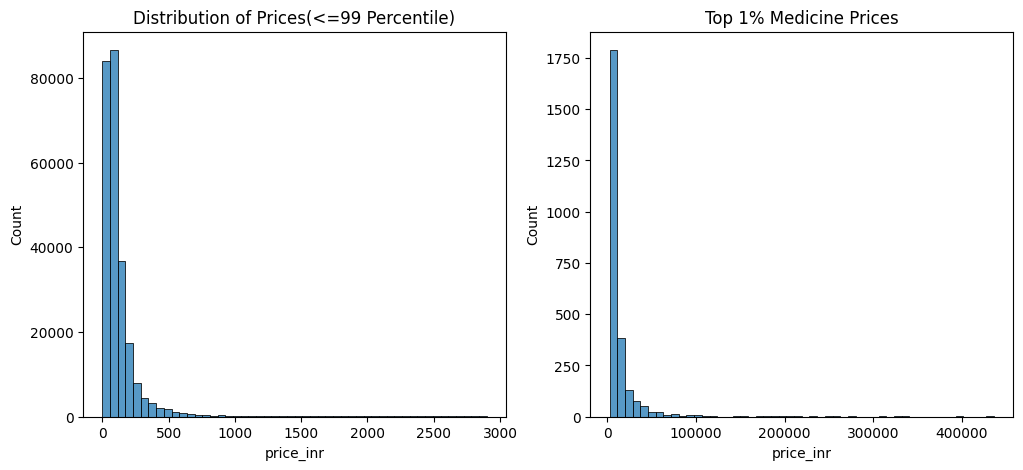

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(x=(df[df['price_inr']<=df['price_inr'].quantile(0.99)]['price_inr']), edgecolor='black',bins=50)
plt.title('Distribution of Prices(<=99 Percentile)')
plt.subplot(1,2,2)
sns.histplot(x=(df[df['price_inr']>df['price_inr'].quantile(0.99)]['price_inr']), edgecolor='black',bins=50)
plt.title('Top 1% Medicine Prices')
plt.show()



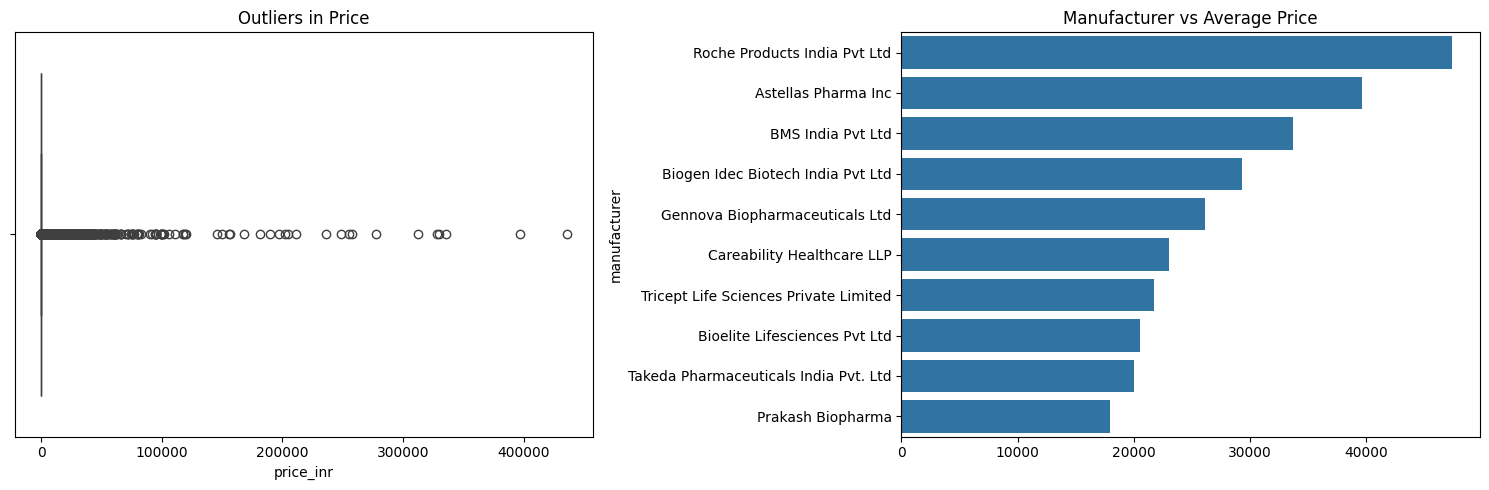

In [18]:
avg_price=df.groupby('manufacturer')['price_inr'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(x=(df['price_inr']))
plt.title("Outliers in Price")
plt.subplot(1,2,2)
sns.barplot(y=avg_price.index,x=avg_price.values,estimator=np.mean)
plt.title("Manufacturer vs Average Price")
plt.tight_layout()
plt.show()



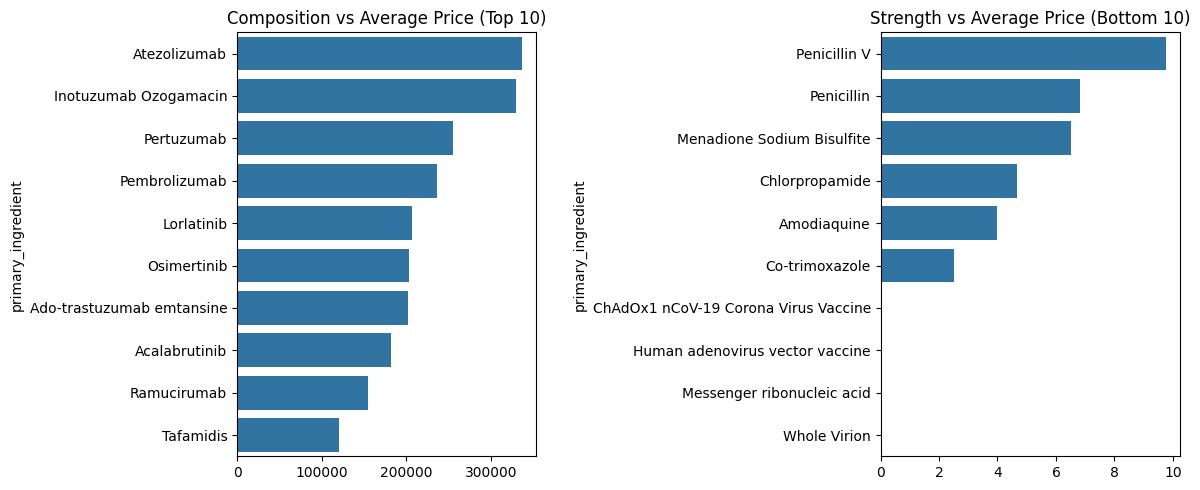

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
avg_price=df.groupby('primary_ingredient')['price_inr'].mean().sort_values(ascending=False).head(10)
sns.barplot(y=avg_price.index,x=avg_price.values,estimator=np.mean)
plt.title("Composition vs Average Price (Top 10)")
plt.subplot(1,2,2)
avg_price=df.groupby('primary_ingredient')['price_inr'].mean().sort_values(ascending=False).tail(10)
sns.barplot(y=avg_price.index,x=avg_price.values,estimator=np.mean)
plt.title("Strength vs Average Price (Bottom 10)")
plt.tight_layout()
plt.show()

# Data Cleaning

In [20]:
df_cleaned=df.copy()

1) Handle Missing Data

In [21]:
df_cleaned.isnull().sum()

,0
product_id,0
brand_name,0
manufacturer,0
price_inr,0
is_discontinued,0
dosage_form,0
pack_size,22330
pack_unit,22330
num_active_ingredients,0
primary_ingredient,0


In [22]:
df_cleaned['pack_size'].fillna(df_cleaned['pack_size'].median(),inplace=True)

In [23]:
df_cleaned['pack_unit'].fillna(df_cleaned['pack_unit'].mode()[0],inplace=True)

In [24]:
df_cleaned['primary_strength'].fillna('Unknown',inplace=True)

2) Remove Duplicates

In [25]:
df_cleaned=df_cleaned.drop_duplicates()

3) Fix Prices

In [26]:
df_cleaned=df_cleaned[df_cleaned['price_inr']>0]

4) Handle Inconsistent Categories

In [27]:
df_cleaned["cleaned_composition"] = (
    df_cleaned["active_ingredients"]
    .str.lower()
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", " ", regex=False)
    .str.replace("/", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.split()
    .apply(lambda x: " ".join(sorted(x)))
)

In [28]:
df_cleaned["cleaned_composition"].nunique()

11671

In [29]:
df_cleaned["brand_name"].nunique()

249394

In [30]:
df_cleaned["manufacturer"].nunique()

7647

# Data Preprocessing

1) Drop Unneccesary Columns

In [31]:
df_cleaned = df_cleaned.drop(columns=["product_id","manufacturer_raw","packaging_raw","active_ingredients"]).copy()

2) Label Encoding

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_cleaned["manufacturer"] = le.fit_transform(df_cleaned["manufacturer"].astype(str))
df_cleaned["primary_ingredient"] = le.fit_transform(df_cleaned["primary_ingredient"].astype(str))
df_cleaned["primary_strength"] = le.fit_transform(df_cleaned["primary_strength"].astype(str))
df_cleaned["therapeutic_class"] = le.fit_transform(df_cleaned["therapeutic_class"].astype(str))
df_cleaned["cleaned_composition"] = le.fit_transform(df_cleaned["cleaned_composition"].astype(str))


In [33]:
df_cleaned.head(10)

,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,therapeutic_class,cleaned_composition
0,Augmentin 625 Duo Tablet,2764,223.42,False,tablet,10.0,strip,2,79,526,2,3119
1,Azithral 500 Tablet,356,132.36,False,tablet,5.0,strip,1,126,526,2,7483
2,Ascoril LS Syrup,2771,118.00,False,syrup,100.0,bottle,2,63,429,7,3911
3,Allegra 120mg Tablet,5987,218.81,False,tablet,10.0,strip,1,588,199,5,2938
4,Avil 25 Tablet,5987,10.96,False,tablet,15.0,strip,1,1122,372,10,5842
5,Allegra-M Tablet,5987,241.48,False,tablet,10.0,strip,2,967,171,5,2021
6,Amoxyclav 625 Tablet,89,223.27,False,tablet,10.0,strip,2,79,526,2,3119
7,Azee 500 Tablet,1619,132.38,False,tablet,5.0,strip,1,126,526,2,7483
8,Atarax 25mg Tablet,2109,85.50,False,tablet,15.0,strip,1,711,372,10,5808
9,Ascoril D Plus Syrup Sugar Free,2771,129.00,False,syrup,100.0,bottle,2,1128,564,5,6025


3. One Hot Encoding

In [34]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["dosage_form", "pack_unit"],drop_first=True)

In [35]:
df_cleaned['is_discontinued'] = df_cleaned['is_discontinued'].astype(int)

In [36]:
df_cleaned.head(10)

,brand_name,manufacturer,price_inr,is_discontinued,pack_size,num_active_ingredients,primary_ingredient,primary_strength,therapeutic_class,cleaned_composition,...,dosage_form_solution,dosage_form_spray,dosage_form_suspension,dosage_form_syrup,dosage_form_tablet,pack_unit_gm,pack_unit_ml,pack_unit_strip,pack_unit_tube,pack_unit_units
0,Augmentin 625 Duo Tablet,2764,223.42,0,10.0,2,79,526,2,3119,...,False,False,False,False,True,False,False,True,False,False
1,Azithral 500 Tablet,356,132.36,0,5.0,1,126,526,2,7483,...,False,False,False,False,True,False,False,True,False,False
2,Ascoril LS Syrup,2771,118.00,0,100.0,2,63,429,7,3911,...,False,False,False,True,False,False,False,False,False,False
3,Allegra 120mg Tablet,5987,218.81,0,10.0,1,588,199,5,2938,...,False,False,False,False,True,False,False,True,False,False
4,Avil 25 Tablet,5987,10.96,0,15.0,1,1122,372,10,5842,...,False,False,False,False,True,False,False,True,False,False
5,Allegra-M Tablet,5987,241.48,0,10.0,2,967,171,5,2021,...,False,False,False,False,True,False,False,True,False,False
6,Amoxyclav 625 Tablet,89,223.27,0,10.0,2,79,526,2,3119,...,False,False,False,False,True,False,False,True,False,False
7,Azee 500 Tablet,1619,132.38,0,5.0,1,126,526,2,7483,...,False,False,False,False,True,False,False,True,False,False
8,Atarax 25mg Tablet,2109,85.50,0,15.0,1,711,372,10,5808,...,False,False,False,False,True,False,False,True,False,False
9,Ascoril D Plus Syrup Sugar Free,2771,129.00,0,100.0,2,1128,564,5,6025,...,False,False,False,True,False,False,False,False,False,False


In [37]:
boolcol=['dosage_form_cream', 'dosage_form_drops', 'dosage_form_gel',
       'dosage_form_inhaler', 'dosage_form_injection', 'dosage_form_ointment',
       'dosage_form_other', 'dosage_form_powder', 'dosage_form_respules',
       'dosage_form_solution', 'dosage_form_spray', 'dosage_form_suspension',
       'dosage_form_syrup', 'dosage_form_tablet','pack_unit_gm',
       'pack_unit_ml', 'pack_unit_strip', 'pack_unit_tube', 'pack_unit_units','pack_size']
df_cleaned[boolcol]=df_cleaned[boolcol].astype(int)

In [38]:
df_cleaned.head(10)

,brand_name,manufacturer,price_inr,is_discontinued,pack_size,num_active_ingredients,primary_ingredient,primary_strength,therapeutic_class,cleaned_composition,...,dosage_form_solution,dosage_form_spray,dosage_form_suspension,dosage_form_syrup,dosage_form_tablet,pack_unit_gm,pack_unit_ml,pack_unit_strip,pack_unit_tube,pack_unit_units
0,Augmentin 625 Duo Tablet,2764,223.42,0,10,2,79,526,2,3119,...,0,0,0,0,1,0,0,1,0,0
1,Azithral 500 Tablet,356,132.36,0,5,1,126,526,2,7483,...,0,0,0,0,1,0,0,1,0,0
2,Ascoril LS Syrup,2771,118.00,0,100,2,63,429,7,3911,...,0,0,0,1,0,0,0,0,0,0
3,Allegra 120mg Tablet,5987,218.81,0,10,1,588,199,5,2938,...,0,0,0,0,1,0,0,1,0,0
4,Avil 25 Tablet,5987,10.96,0,15,1,1122,372,10,5842,...,0,0,0,0,1,0,0,1,0,0
5,Allegra-M Tablet,5987,241.48,0,10,2,967,171,5,2021,...,0,0,0,0,1,0,0,1,0,0
6,Amoxyclav 625 Tablet,89,223.27,0,10,2,79,526,2,3119,...,0,0,0,0,1,0,0,1,0,0
7,Azee 500 Tablet,1619,132.38,0,5,1,126,526,2,7483,...,0,0,0,0,1,0,0,1,0,0
8,Atarax 25mg Tablet,2109,85.50,0,15,1,711,372,10,5808,...,0,0,0,0,1,0,0,1,0,0
9,Ascoril D Plus Syrup Sugar Free,2771,129.00,0,100,2,1128,564,5,6025,...,0,0,0,1,0,0,0,0,0,0


# First Model

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

1. Training and testing data

In [40]:
X1=df_cleaned.drop(columns=['price_inr','brand_name'])
y1 = np.log1p(df_cleaned['price_inr']) #using a log transformation on the target (price_inr) due to right skewness

In [41]:
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)

2. Model training

In [42]:
model1=RandomForestRegressor(
   n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1  )
model1.fit(X1_train,y1_train)

RandomForestRegressor(max_features=0.7, min_samples_leaf=2, min_samples_split=4,
                      n_estimators=300, n_jobs=-1, random_state=42)

3. Evaluation

In [43]:
y1_pred=model1.predict(X1_test)
y1_pred = np.expm1(y1_pred)
y1_test_original = np.expm1(y1_test) # Inverse transform y1_test
r2=r2_score(y1_test_original,y1_pred)
print(r2)

0.15022721697640407


In [44]:
mae=mean_absolute_error(y1_test_original,y1_pred)
print(mae)

135.59523973994726


#Second Model (Used in the app)

In [45]:
print((df["price_inr"] > 10000).sum())
print((df["price_inr"] > 50000).sum())
print((df["price_inr"] > 100000).sum())

868
96
31


We see that the dataset is heavily right skewed and the most expensive medicines is concentrated in the top 1% of the whole dataset.

In [46]:
df_trim = df_cleaned[df_cleaned["price_inr"] <= df_cleaned["price_inr"].quantile(0.99)].copy()

1. Training and testing data

In [47]:
X2=df_trim.drop(columns=['price_inr','brand_name'])
y2 = np.log1p(df_trim['price_inr']) #using a log transformation on the target (price_inr) due to right skewness

In [48]:
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2,random_state=42)

2. Model training

In [49]:
model2=RandomForestRegressor(
   n_estimators=95,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.7,
    bootstrap=True,
    random_state=42,
    n_jobs=-1  )
model2.fit(X2_train,y2_train)

RandomForestRegressor(max_depth=25, max_features=0.7, min_samples_leaf=2,
                      min_samples_split=4, n_estimators=95, n_jobs=-1,
                      random_state=42)

3. Evaluation

In [50]:
y2_pred=model2.predict(X2_test)
y2_pred = np.expm1(y2_pred)
y2_test_original = np.expm1(y2_test)  # Inverse transform y2_test
r2=r2_score(y2_test_original,y2_pred)
print(r2)

0.70877922963874


In [51]:
mae2=mean_absolute_error(y2_test_original,y2_pred)
print(mae2)

37.32246521719048


4. Saving model and processed dataset.

In [52]:
df_cleaned.to_csv('medicine_price.csv',index=False)

In [53]:
import joblib

joblib.dump(model2,'medicine_price_model.pkl',compress=3)

['medicine_price_model.pkl']